# Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import  GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [4]:
df = pd.read_csv("../../Data/Processed/Master/featured_dataset.csv")

print(df.shape)
df.head()

(98914, 50)


,RaceID,Year,RaceName,Circuit,Driver,Team,LapNumber,Position,LapTime_Seconds,Compound,...,IsOldTire,IsLongStint,DegradationRate,LapLengthFactor,CornerDensity,DRS_per_km,TempDifference,IsHotTrack,IsHotAir,TempCategory
0,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,1,17.0,100.625,MEDIUM,...,False,False,NaN,1.0446,3.0297,0.3787,6.6,False,False,Medium
1,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,2,18.0,93.560,MEDIUM,...,False,False,NaN,1.0446,3.0297,0.3787,6.6,False,False,Medium
2,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,3,18.0,91.768,MEDIUM,...,False,False,-4.0,1.0446,3.0297,0.3787,6.7,False,False,Medium
3,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,4,18.0,91.591,MEDIUM,...,False,False,-3.0,1.0446,3.0297,0.3787,6.1,False,False,Medium
4,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,5,18.0,91.422,MEDIUM,...,False,False,-2.0,1.0446,3.0297,0.3787,6.0,False,False,Medium


## Recreating the X test 

In [7]:
df = df[df["ValidLap"]].copy()
metadata_cols = [
    "RaceID",
    "RaceName",
    "ValidLap",
    "ExclusionReason"
]

leakage_cols = [
    "LapDelta",
    "DegradationRate",
    "PitInTime",
    "PitOutTime"
]

target = "LapTime_Seconds"


In [8]:
df = df.drop(columns=metadata_cols)

train_df = df[df["Year"] < 2025].copy()
test_df = df[df["Year"] == 2025].copy()

X_train = train_df.drop(columns=[target] + leakage_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=[target] + leakage_cols)
y_test = test_df[target]

In [9]:
cat_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns

print(cat_cols.tolist())

['Circuit', 'Driver', 'Team', 'Compound', 'Direction', 'HighSpeedCircuit', 'SurfaceAbrasion', 'IsFinal10Laps', 'RaceHalf', 'IsFreshTire', 'IsOldTire', 'IsLongStint', 'IsHotTrack', 'IsHotAir', 'TempCategory']


In [10]:
X_train = pd.get_dummies(
    X_train,
    columns=cat_cols
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [11]:
train_mask = X_train.notna().all(axis=1)
X_train = X_train[train_mask]
y_train = y_train[train_mask]

test_mask = X_test.notna().all(axis=1)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

## Importing model

In [12]:
import joblib

GB = joblib.load(
    "../Models/gradient_boosting_model.pkl"
)

In [13]:
y_pred = GB.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 2.478
RMSE: 5.917
R²  : 0.797


## Predicted vs Actual

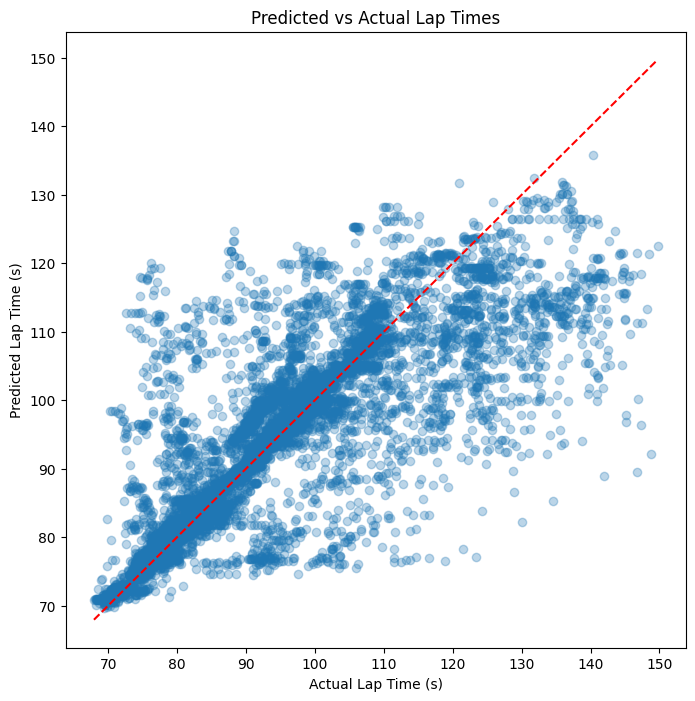

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Predicted vs Actual Lap Times")

plt.show()

## Residuals

In [ ]:
residuals = y_test - y_pred

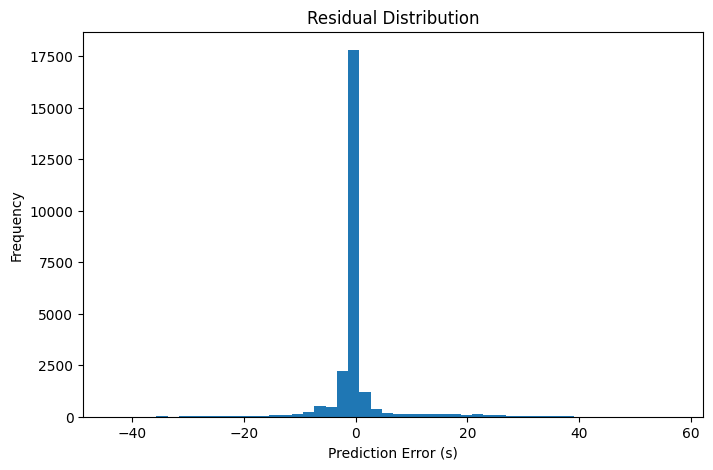

In [17]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=50)

plt.xlabel("Prediction Error (s)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

## Residuals vs Predictions

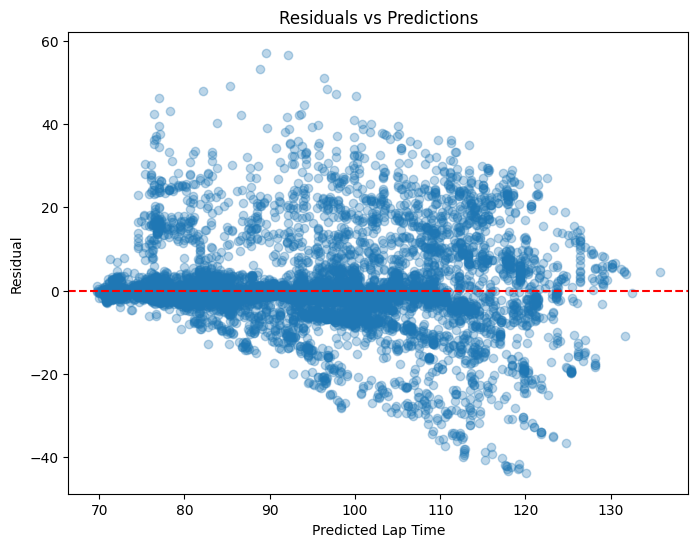

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Lap Time")

plt.ylabel("Residual")

plt.title("Residuals vs Predictions")

plt.show()

## Performance by tyre compound

In [20]:
print("test_df:", len(test_df))
print("X_test:", len(X_test))
print("y_test:", len(y_test))
print("y_pred:", len(y_pred))

test_df: 26317
X_test: 24985
y_test: 24985
y_pred: 24985


In [21]:
results = test_df.loc[X_test.index].copy()

results["Prediction"] = y_pred

In [22]:
compound_metrics = []

for compound, group in results.groupby("Compound"):

    mae = mean_absolute_error(
        group[target],
        group["Prediction"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group[target],
            group["Prediction"]
        )
    )

    r2 = r2_score(
        group[target],
        group["Prediction"]
    )

    compound_metrics.append(
        [compound, mae, rmse, r2]
    )

compound_metrics = pd.DataFrame(
    compound_metrics,
    columns=[
        "Compound",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(compound_metrics)

,Compound,MAE,RMSE,R²
0,HARD,2.082436,5.289256,0.803212
1,INTERMEDIATE,7.507571,10.373188,0.556618
2,MEDIUM,2.095841,5.311416,0.830566
3,SOFT,2.959454,7.106794,0.665663


In [23]:
results.groupby("Compound").size()

Compound
HARD            10615
INTERMEDIATE     1291
MEDIUM           9949
SOFT             3130
dtype: int64

the modek is strongest in dry conditions, particularly on Medium and Hard tyres. Performance decreases for Soft tyres and significantly decreases for Intermediate tyres, suggesting that changing weather and track conditions are not being fully captured by the current feature set.

## Performance by circuit

In [26]:
circuit_metrics = []

for circuit, group in results.groupby("Circuit"):

    mae = mean_absolute_error(
        group[target],
        group["Prediction"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group[target],
            group["Prediction"]
        )
    )

    r2 = r2_score(
        group[target],
        group["Prediction"]
    )

    circuit_metrics.append(
        [circuit, len(group), mae, rmse, r2]
    )

circuit_metrics = pd.DataFrame(
    circuit_metrics,
    columns=["Circuit", "Samples", "MAE", "RMSE", "R²"]
)

display(circuit_metrics.sort_values("MAE"))

,Circuit,Samples,MAE,RMSE,R²
3,Budapest,1328,0.698507,1.331703,0.807578
22,Yas Island,1116,0.751321,1.575235,0.776211
20,Suzuka,1019,0.786001,1.613846,0.760107
5,Jeddah,824,0.936193,1.566533,0.675376
8,Marina Bay,1189,1.090370,2.084504,0.560438
16,Shanghai,1025,1.134245,2.575930,0.457188
10,Mexico City,1222,1.257200,3.129520,0.389670
14,Monza,936,1.273530,1.995965,0.651613
1,Baku,872,1.310795,2.279555,0.386111
19,Spielberg,1090,1.557349,3.535946,0.578127


Performance varied considerably across circuits, with MAE ranging from 0.70 seconds at Budapest to 10.87 seconds at Melbourne. Since all circuits contained substantial numbers of test samples, these differences cannot be attributed solely to insufficient sample size. This suggests that the model captures general lap-time patterns effectively but struggles with certain circuit-specific dynamics and atypical race conditions.

Melborne worst predication cause models preformance dominated by dry laps

## Worst predictions